In [29]:
# ==========================================================
#MobileNetV3 Real-Time
# ==========================================================

import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class MobileNetV3Fusion(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()

        backbone = models.mobilenet_v3_large(weights="DEFAULT")

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.img_fc = nn.Sequential(
            nn.Linear(960, 256),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.20)
        )

        self.classifier = nn.Sequential(
            nn.Linear(320, 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, 2)
        )

    def forward(self, image, meta):

        x = self.features(image)
        x = self.pool(x).flatten(1)

        img_feat = self.img_fc(x)
        meta_feat = self.meta_fc(meta)

        x = torch.cat([img_feat, meta_feat], dim=1)

        return self.classifier(x)


model = MobileNetV3Fusion(len(feature_cols)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


best_acc = 0
patience = 5
counter = 0
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    train_preds = []
    train_true = []

    for images, meta, labels in tqdm(train_loader):

        images = images.to(device)
        meta   = meta.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images, meta)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)

        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_true, train_preds)

    model.eval()

    val_preds = []
    val_probs = []
    val_true  = []

    with torch.no_grad():

        for images, meta, labels in val_loader:

            images = images.to(device)
            meta   = meta.to(device)

            outputs = model(images, meta)

            probs = torch.softmax(outputs, dim=1)[:,1]
            preds = outputs.argmax(1)

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_mobilenetv3.pth")
        counter = 0
        print("BEST MODEL SAVED")
    else:
        counter += 1

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val   Acc: {val_acc:.4f}")
    print(f"Val   AUC: {val_auc:.4f}")
    print("-"*50)

    if counter >= patience:
        print("EARLY STOPPING")
        break


print("Best Validation Accuracy:", best_acc)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 151MB/s]


  0%|          | 0/962 [00:00<?, ?it/s]

BEST MODEL SAVED

Epoch 1/20
Train Acc: 0.7657
Val   Acc: 0.7995
Val   AUC: 0.8957
--------------------------------------------------


  0%|          | 0/962 [00:00<?, ?it/s]

...


Epoch 4/20
Train Acc: 0.8630
Val   Acc: 0.6466
Val   AUC: 0.8908
--------------------------------------------------


  0%|          | 0/962 [00:00<?, ?it/s]


Epoch 5/20
Train Acc: 0.8757
Val   Acc: 0.6904
Val   AUC: 0.9021
--------------------------------------------------


  0%|          | 0/962 [00:00<?, ?it/s]


Epoch 6/20
Train Acc: 0.8856
Val   Acc: 0.7885
Val   AUC: 0.9058
--------------------------------------------------
EARLY STOPPING
Best Validation Accuracy: 0.7995124923826935


In [1]:
# ============================================================
# OPTIMIZED KAGGLE GPU VERSION
# CUDA + AMP + cuDNN + tqdm + Faster DataLoader
# Multimodal Cross Attention Skin Lesion Model
# ============================================================

import os, gc, time, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# 1. MAX GPU PERFORMANCE
# ============================================================
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# 2. PATHS (REPLACE IF NEEDED)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset"
IMG_PATH  = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
CSV_PATH  = "/kaggle/input/datasets/abdelrahmanelkassem/project/final_preprocessed_data.csv"

# ============================================================
# 3. LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
available_images = set(os.listdir(IMG_PATH))

def clean_name(x):
    x = str(x)
    x = x.replace("_mel.jpg", ".jpg")
    x = x.replace("_oth.jpg", ".jpg")
    x = x.replace("ISIC2019_", "ISIC_")
    x = x.replace("ISIC2020_", "ISIC_")
    x = x.replace("ISIC2018_", "ISIC_")
    x = x.replace("ISIC2017_", "ISIC_")
    return x

df["image"] = df["image"].apply(clean_name)
df["exists"] = df["image"].isin(available_images)
df = df[df["exists"]].reset_index(drop=True)

print("Matched Images:", len(df))

# ============================================================
# 4. FEATURES
# ============================================================
drop_cols = ["image", "class", "exists", "isic_id", "patient_id"]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

print("Metadata Features:", len(feature_cols))

# ============================================================
# 5. SPLIT (PATIENT SAFE)
# ============================================================
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

# ============================================================
# 6. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.15,0.15,0.15,0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# ============================================================
# 7. DATASET
# ============================================================
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(
            os.path.join(IMG_PATH, row["image"])
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        meta = torch.tensor(
            row[feature_cols].values.astype(np.float32)
        )

        label = torch.tensor(
            int(row["class"])
        ).long()

        return img, meta, label

# ============================================================
# 8. BALANCED SAMPLER
# ============================================================
labels = train_df["class"].values
class_counts = np.bincount(labels)

weights = 1.0 / class_counts
sample_weights = [weights[x] for x in labels]

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    len(sample_weights)
)

# ============================================================
# 9. DATALOADERS (FAST)
# ============================================================
train_loader = DataLoader(
    SkinDataset(train_df, train_transform),
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    SkinDataset(val_df, val_transform),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# 10. MODEL
# ============================================================
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()

        backbone = models.efficientnet_b3(weights="DEFAULT")

        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.img_fc = nn.Linear(1536, 256)

        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim,128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2)
        )

        self.query = nn.Linear(256,128)
        self.key   = nn.Linear(128,128)
        self.value = nn.Linear(128,128)

        self.classifier = nn.Sequential(
            nn.Linear(384,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,2)
        )

    def forward(self,image,meta):

        x = self.cnn(image)
        x = self.pool(x).flatten(1)

        img_feat = self.img_fc(x)
        meta_feat = self.meta_fc(meta)

        q = self.query(img_feat).unsqueeze(1)
        k = self.key(meta_feat).unsqueeze(1)
        v = self.value(meta_feat).unsqueeze(1)

        attn = torch.softmax(
            torch.bmm(q,k.transpose(1,2))/np.sqrt(128),
            dim=-1
        )

        attended = torch.bmm(attn,v).squeeze(1)

        fused = torch.cat([img_feat, attended], dim=1)

        return self.classifier(fused)

model = CrossAttentionFusionModel(
    len(feature_cols)
).to(device)

# ============================================================
# 11. TRAIN SETUP
# ============================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

scaler = GradScaler()

# ============================================================
# 12. TRAIN LOOP
# ============================================================
best_acc = 0
patience = 5
counter = 0
EPOCHS = 25

history = {
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):

    start = time.time()
    model.train()

    train_preds = []
    train_true = []

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=False
    )

    for images, meta, labels in loop:

        images = images.to(device, non_blocking=True)
        meta   = meta.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images, meta)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(1)

        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

        loop.set_postfix(loss=float(loss))

    train_acc = accuracy_score(train_true, train_preds)

    # ================= VALIDATION =================
    model.eval()

    val_preds = []
    val_probs = []
    val_true  = []

    with torch.no_grad():

        for images, meta, labels in tqdm(
            val_loader,
            desc="Validating",
            leave=False
        ):

            images = images.to(device, non_blocking=True)
            meta   = meta.to(device, non_blocking=True)

            with autocast():
                outputs = model(images, meta)

            probs = torch.softmax(outputs,1)[:,1]
            preds = outputs.argmax(1)

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("BEST MODEL SAVED")
    else:
        counter += 1

    mins = (time.time() - start) / 60

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print(f"Val AUC   : {val_auc:.4f}")
    print(f"Time      : {mins:.2f} min")
    print("-"*50)

    if counter >= patience:
        print("EARLY STOPPING")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("\nBest Validation Accuracy:", best_acc)

Using Device: cuda
GPU: Tesla T4
Matched Images: 17019
Metadata Features: 30
Train: 15378
Val: 1641
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 135MB/s] 
/tmp/ipykernel_55/1081515002.py:263: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/1081515002.py:301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_55/1081515002.py:315: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loop.set_postfix(loss=float(loss))


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

...

Epoch 12/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/1081515002.py:301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

/tmp/ipykernel_55/1081515002.py:337: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 12/25
Train Acc : 0.9305
Val Acc   : 0.8263
Val AUC   : 0.9200
Time      : 2.71 min
--------------------------------------------------
EARLY STOPPING

Best Validation Accuracy: 0.8415600243753809


  0%|          | 0/52 [00:00<?, ?it/s]

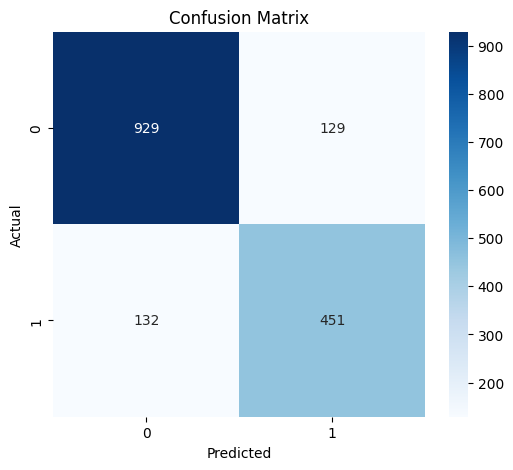

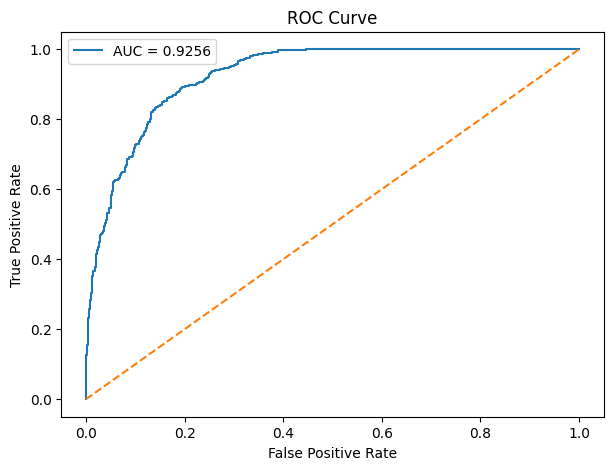

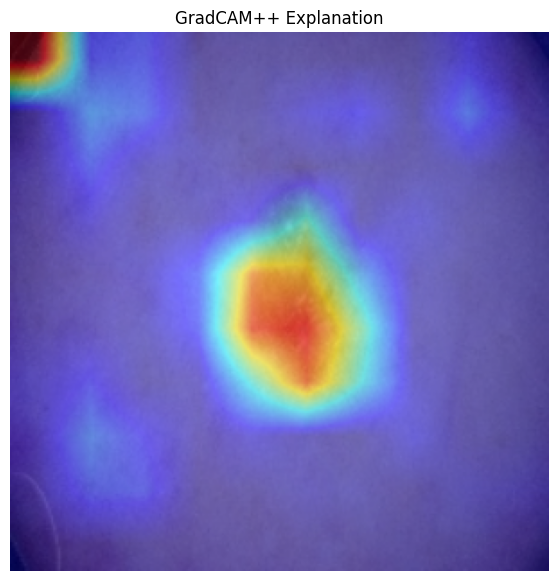

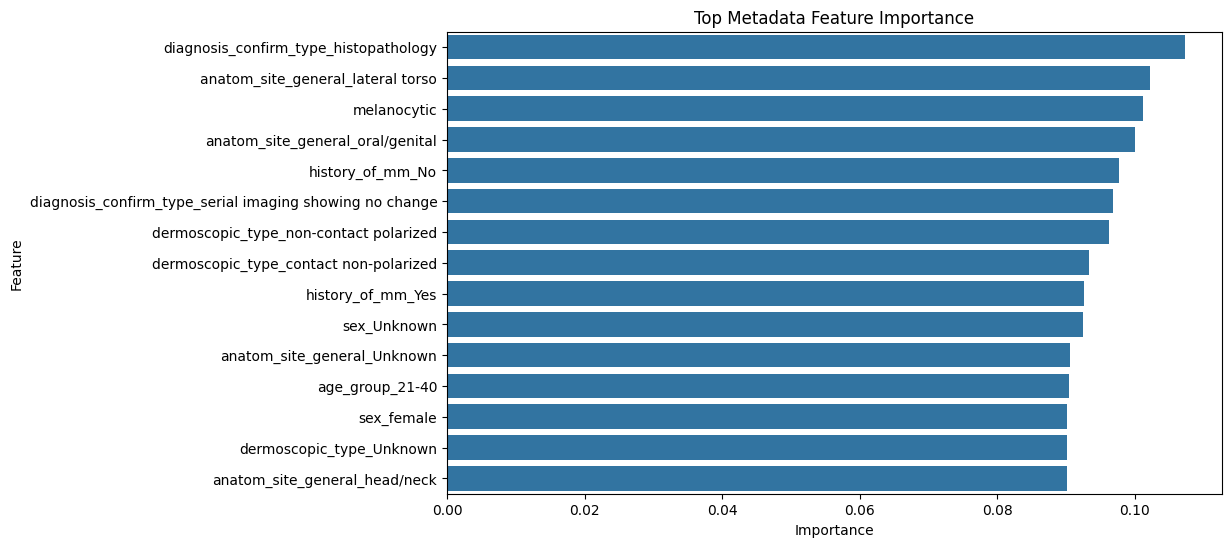

In [3]:
# ============================================================
# INSTALL
# ============================================================
!pip install -q grad-cam shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import cv2

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix, roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD BEST MODEL
# ============================================================
model = CrossAttentionFusionModel(len(feature_cols)).to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ============================================================
# 1. EVALUATE + COLLECT PREDICTIONS
# ============================================================
all_preds = []
all_probs = []
all_true = []

with torch.no_grad():
    for images, meta, labels in tqdm(val_loader):
        images = images.to(device)
        meta   = meta.to(device)

        outputs = model(images, meta)
        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 3. ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 4. GRADCAM++ IMAGE EXPLANATION
# ============================================================
target_layers = [model.cnn[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)
val_ds = SkinDataset(val_df, val_transform)
# sample image from validation set
sample_img, sample_meta, sample_label = val_ds[0]

input_tensor = sample_img.unsqueeze(0).to(device)
meta_tensor  = sample_meta.unsqueeze(0).to(device)

# wrapper because model needs image+meta
class Wrapper(torch.nn.Module):
    def __init__(self, base_model, meta):
        super().__init__()
        self.base_model = base_model
        self.meta = meta

    def forward(self, x):
        return self.base_model(x, self.meta)

wrapped = Wrapper(model, meta_tensor).to(device)

cam = GradCAMPlusPlus(
    model=wrapped,
    target_layers=[wrapped.base_model.cnn[-1]]
)

grayscale_cam = cam(input_tensor=input_tensor)[0]

# convert image back to displayable
img_np = sample_img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(7,7))
plt.imshow(visualization)
plt.title("GradCAM++ Explanation")
plt.axis("off")
plt.show()

# ============================================================
# 5. SIMPLE METADATA IMPORTANCE (WEIGHT BASED)
# ============================================================
meta_weights = model.meta_fc[0].weight.detach().cpu().numpy()
importance = np.mean(np.abs(meta_weights), axis=0)

imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="Importance", y="Feature")
plt.title("Top Metadata Feature Importance")
plt.show()

# ============================================================
# 6. OPTIONAL: SAVE FIGURES
# ============================================================
# plt.savefig("figure.png", dpi=300, bbox_inches="tight")

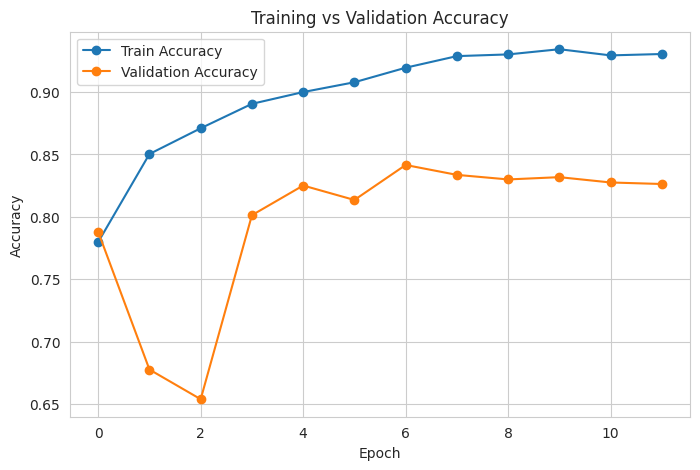

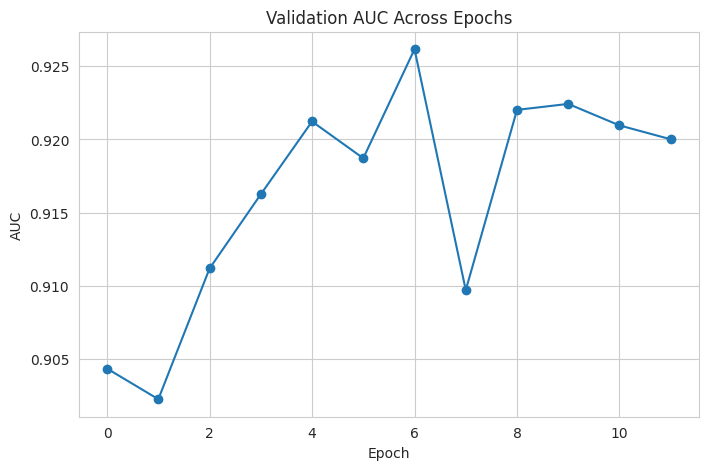

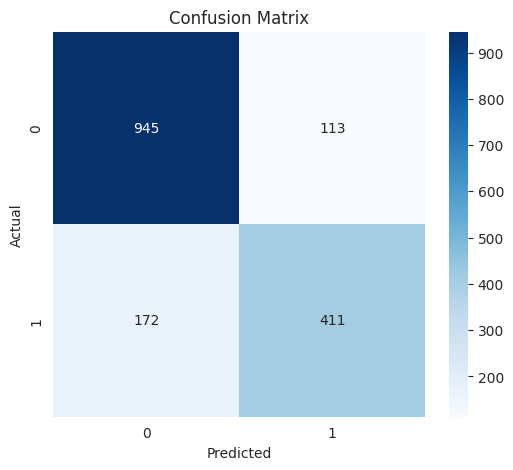

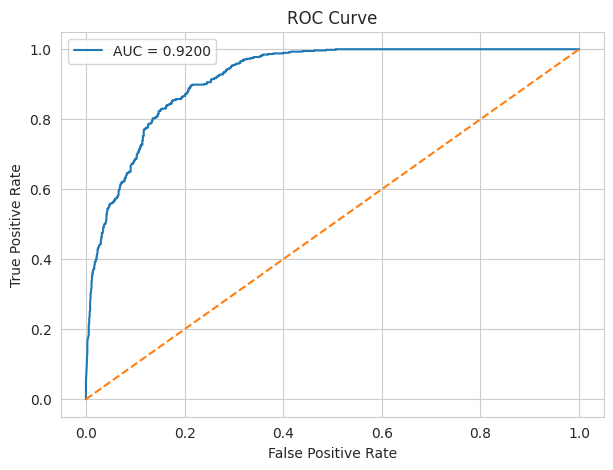

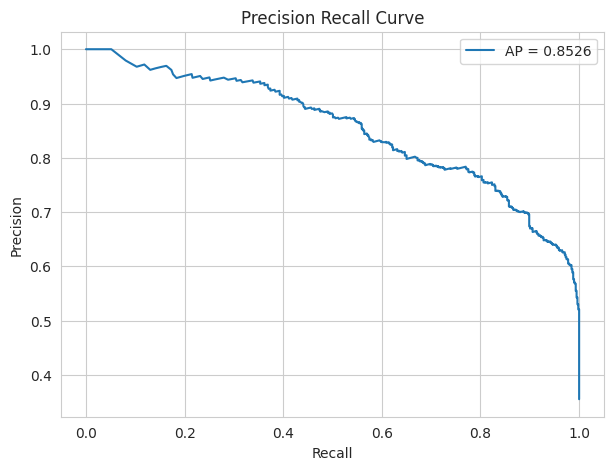

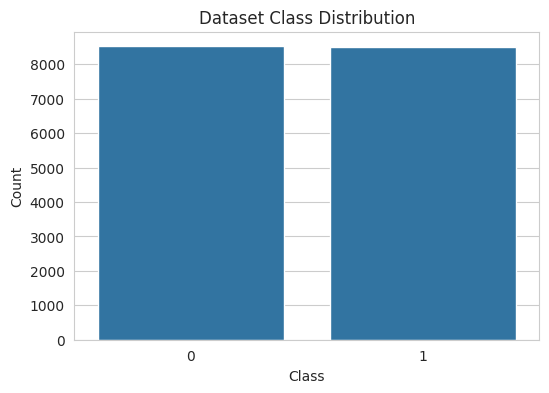

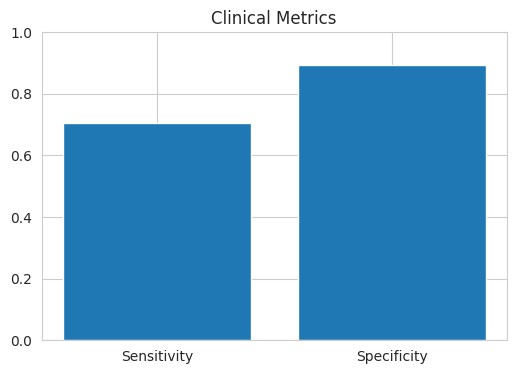

In [4]:
# ============================================================
# IMPORTANT GRAPH PACK FOR YOUR PROJECT (KAGGLE READY)
# Run AFTER training is finished
# Uses history + val predictions + trained model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

sns.set_style("whitegrid")

# ============================================================
# REQUIRED VARIABLES FROM TRAINING:
# history["train_acc"]
# history["val_acc"]
# history["val_auc"]
# val_true
# val_preds
# val_probs
# ============================================================


# ============================================================
# 1. TRAIN vs VALIDATION ACCURACY
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# ============================================================
# 2. VALIDATION AUC CURVE OVER EPOCHS
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["val_auc"], marker='o')
plt.title("Validation AUC Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 4. ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ============================================================
# 5. PRECISION-RECALL CURVE
# ============================================================
precision, recall, _ = precision_recall_curve(val_true, val_probs)
ap = average_precision_score(val_true, val_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================
plt.figure(figsize=(6,4))
sns.countplot(x=df["class"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# ============================================================
# 7. SENSITIVITY / SPECIFICITY
# ============================================================
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(6,4))
plt.bar(
    ["Sensitivity", "Specificity"],
    [sensitivity, specificity]
)
plt.ylim(0,1)
plt.title("Clinical Metrics")
plt.show()


# ============================================================
# 8. SAVE FIGURES (OPTIONAL)
# ============================================================
# plt.savefig("figure_name.png", dpi=300, bbox_inches="tight")

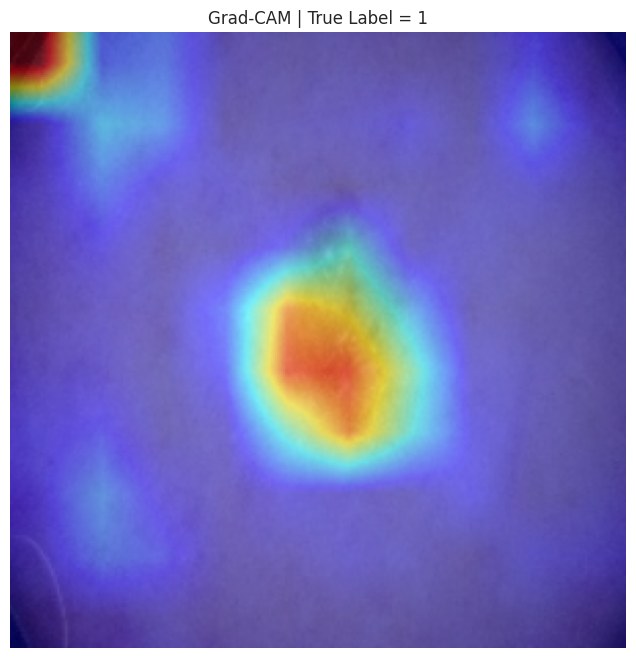

In [6]:
!pip install -q grad-cam

import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# LOAD MODEL
# =====================================================
model = CrossAttentionFusionModel(len(feature_cols)).to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# =====================================================
# REBUILD VALIDATION DATASET
# =====================================================
val_ds = SkinDataset(val_df, val_transform)

# sample
img, meta, label = val_ds[0]

input_tensor = img.unsqueeze(0).to(device)
meta_tensor  = meta.unsqueeze(0).to(device)

# =====================================================
# WRAPPER
# =====================================================
class Wrapper(torch.nn.Module):
    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta

    def forward(self, x):
        return self.model(x, self.meta)

wrapped_model = Wrapper(model, meta_tensor).to(device)
wrapped_model.eval()

# =====================================================
# TARGET LAYER
# =====================================================
target_layers = [wrapped_model.model.cnn[-1]]

cam = GradCAM(
    model=wrapped_model,
    target_layers=target_layers
)

# =====================================================
# GENERATE HEATMAP
# =====================================================
grayscale_cam = cam(input_tensor=input_tensor)[0]

# =====================================================
# DISPLAY
# =====================================================
img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title(f"Grad-CAM | True Label = {label.item()}")
plt.axis("off")
plt.show()

In [7]:
# ============================================================
# OPTIMIZED DENSENET-121 (GPU FAST VERSION)
# Multimodal Skin Lesion Classification
# Swish Activation + Metadata Fusion + XAI Ready
# Kaggle / CUDA Optimized
# ============================================================

import os, gc, time, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# GPU SPEED SETTINGS
# ============================================================
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# PATHS (USE YOUR SAME DATASET)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset"
IMG_PATH  = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
CSV_PATH  = "/kaggle/input/datasets/abdelrahmanelkassem/project/final_preprocessed_data.csv"

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
available_images = set(os.listdir(IMG_PATH))

def clean_name(x):
    x = str(x)
    x = x.replace("_mel.jpg",".jpg")
    x = x.replace("_oth.jpg",".jpg")
    x = x.replace("ISIC2019_","ISIC_")
    x = x.replace("ISIC2020_","ISIC_")
    x = x.replace("ISIC2018_","ISIC_")
    x = x.replace("ISIC2017_","ISIC_")
    return x

df["image"] = df["image"].apply(clean_name)
df["exists"] = df["image"].isin(available_images)
df = df[df["exists"]].reset_index(drop=True)

print("Matched Images:", len(df))

# ============================================================
# FEATURES
# ============================================================
drop_cols = ["image","class","exists","isic_id","patient_id"]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

print("Metadata Features:", len(feature_cols))

# ============================================================
# SPLIT
# ============================================================
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

# ============================================================
# AUGMENTATION
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.15,0.15,0.15,0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# ============================================================
# DATASET
# ============================================================
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            os.path.join(IMG_PATH, row["image"])
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        meta = torch.tensor(
            row[feature_cols].values.astype(np.float32)
        )

        label = torch.tensor(
            int(row["class"])
        ).long()

        return img, meta, label

# ============================================================
# BALANCED SAMPLER
# ============================================================
labels = train_df["class"].values
counts = np.bincount(labels)
weights = 1.0 / counts

sample_weights = [weights[x] for x in labels]

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    len(sample_weights)
)

# ============================================================
# DATALOADER
# ============================================================
train_loader = DataLoader(
    SkinDataset(train_df, train_tfms),
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    SkinDataset(val_df, val_tfms),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# SWISH ACTIVATION
# ============================================================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# ============================================================
# MODEL
# ============================================================
class DenseNetSwishFusion(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()

        backbone = models.densenet121(weights="DEFAULT")

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.img_fc = nn.Sequential(
            nn.Linear(1024,256),
            Swish(),
            nn.Dropout(0.2)
        )

        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim,128),
            Swish(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(384,128),
            Swish(),
            nn.Dropout(0.4),
            nn.Linear(128,2)
        )

    def forward(self, image, meta):

        x = self.features(image)
        x = F.relu(x, inplace=True)
        x = self.pool(x).flatten(1)

        img_feat = self.img_fc(x)
        meta_feat = self.meta_fc(meta)

        fused = torch.cat([img_feat, meta_feat], dim=1)

        return self.classifier(fused)

model = DenseNetSwishFusion(
    len(feature_cols)
).to(device)

# ============================================================
# TRAIN SETUP
# ============================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

scaler = GradScaler()

# ============================================================
# TRAIN LOOP
# ============================================================
best_acc = 0
patience = 5
counter = 0
EPOCHS = 25

history = {
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):

    model.train()

    train_preds = []
    train_true = []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, meta, labels in loop:

        images = images.to(device, non_blocking=True)
        meta   = meta.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images, meta)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(1)

        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

        loop.set_postfix(loss=float(loss))

    train_acc = accuracy_score(train_true, train_preds)

    # ================= VALIDATION =================
    model.eval()

    val_preds = []
    val_probs = []
    val_true  = []

    with torch.no_grad():

        for images, meta, labels in tqdm(val_loader, desc="Validating"):

            images = images.to(device, non_blocking=True)
            meta   = meta.to(device, non_blocking=True)

            with autocast():
                outputs = model(images, meta)

            probs = torch.softmax(outputs,1)[:,1]
            preds = outputs.argmax(1)

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_densenet_model.pth")
        print("BEST MODEL SAVED")
    else:
        counter += 1

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc  : {val_acc:.4f}")
    print(f"Val AUC  : {val_auc:.4f}")
    print("-"*50)

    if counter >= patience:
        print("EARLY STOPPING")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("Best Validation Accuracy:", best_acc)

Using: cuda
GPU: Tesla T4
Matched Images: 17019
Metadata Features: 30
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 165MB/s]
/tmp/ipykernel_55/1863326044.py:259: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/1863326044.py:292: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

...

Epoch 14/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/1863326044.py:292: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

/tmp/ipykernel_55/1863326044.py:323: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 14
Train Acc: 0.9196
Val Acc  : 0.8190
Val AUC  : 0.9111
--------------------------------------------------
EARLY STOPPING
Best Validation Accuracy: 0.8287629494210847


  0%|          | 0/52 [00:00<?, ?it/s]

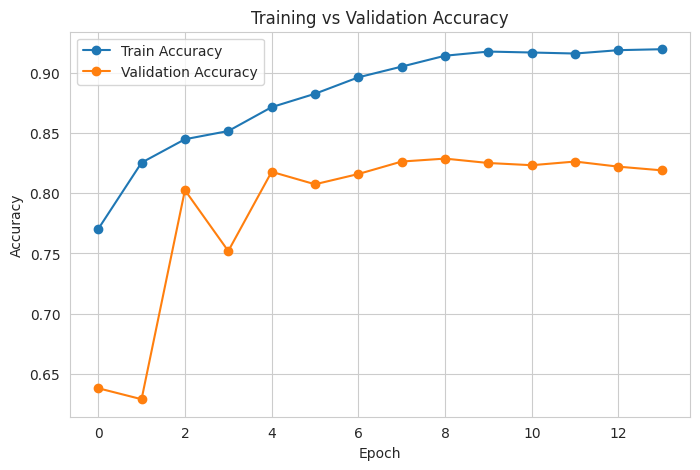

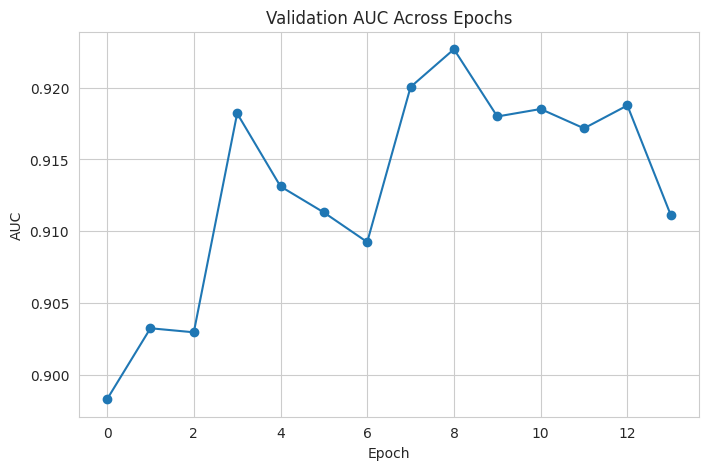

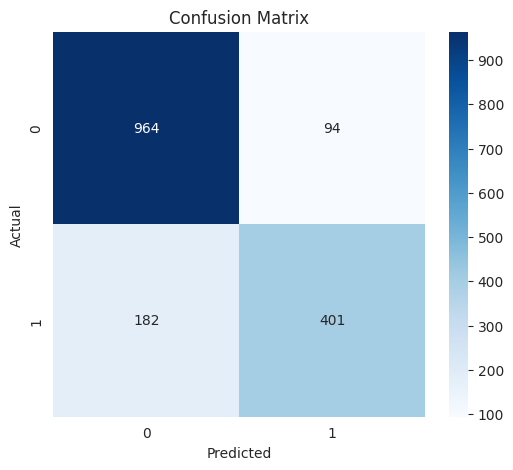

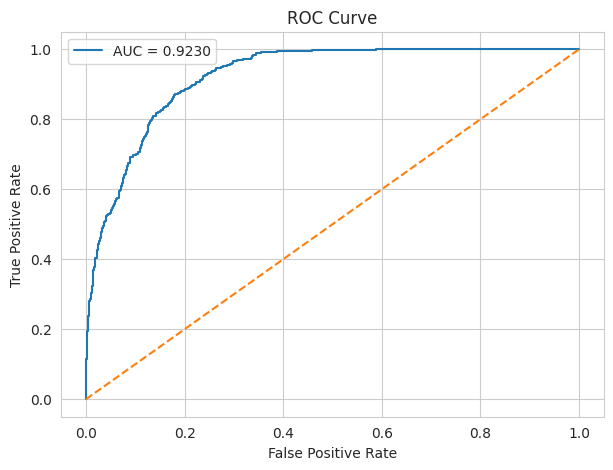

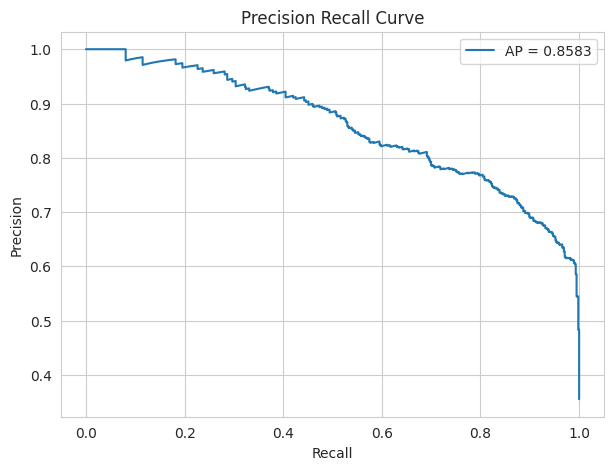

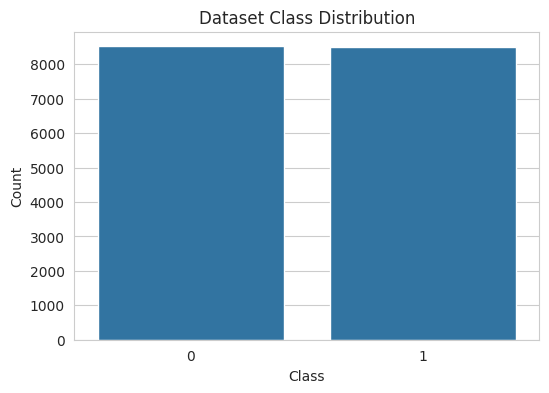

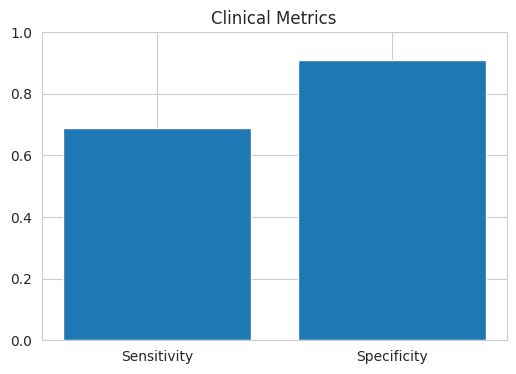

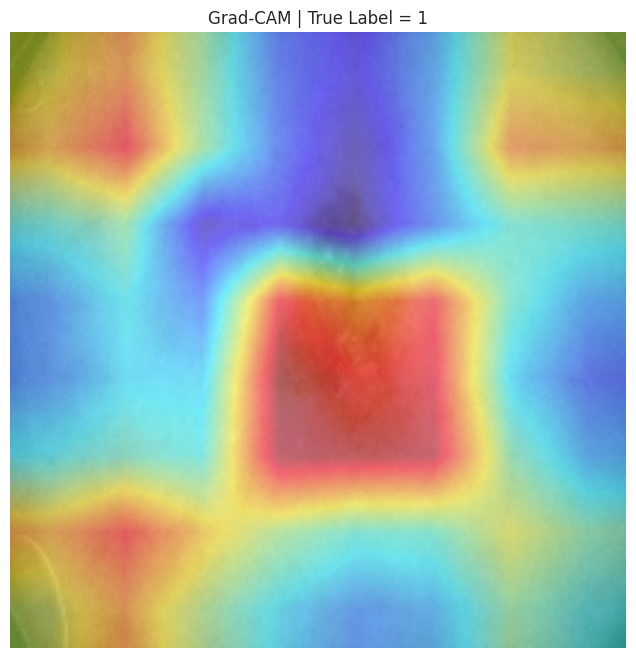

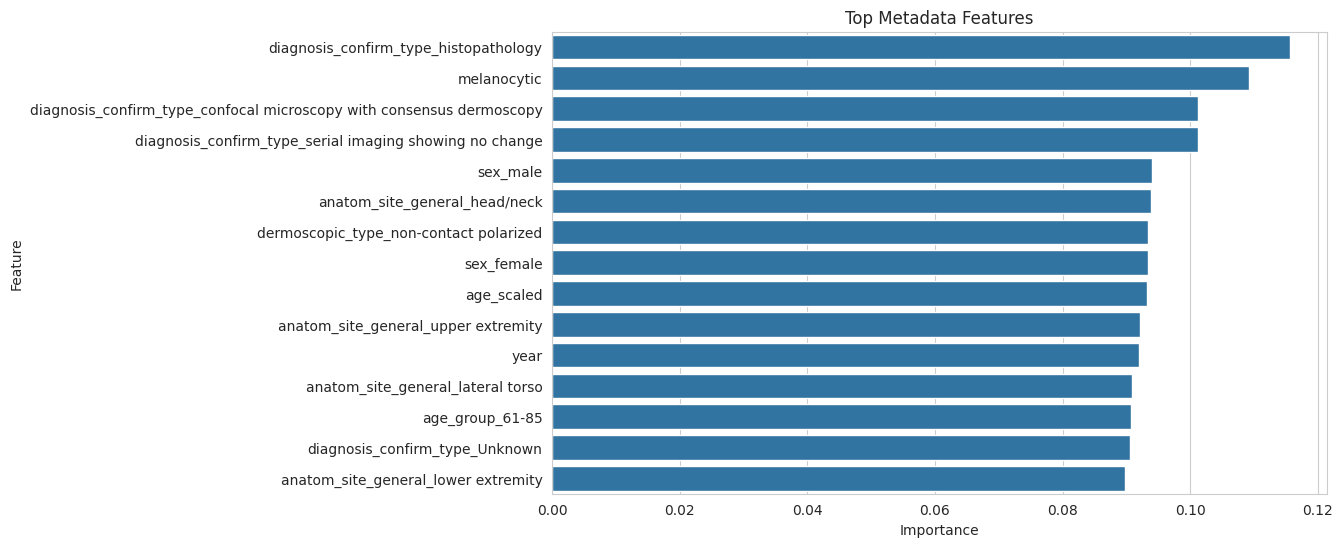

In [8]:
# ============================================================
# XAI + IMPORTANT GRAPHS FOR DenseNet121 + Swish Fusion Model
# Kaggle Ready
# Run AFTER training is finished
# Uses: best_densenet_model.pth
# ============================================================

!pip install -q grad-cam shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_style("whitegrid")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================
model = DenseNetSwishFusion(len(feature_cols)).to(device)
model.load_state_dict(
    torch.load("best_densenet_model.pth", map_location=device)
)
model.eval()

# ============================================================
# VALIDATION DATASET REBUILD
# ============================================================
val_ds = SkinDataset(val_df, val_tfms)

# ============================================================
# EVALUATE MODEL
# ============================================================
val_true  = []
val_preds = []
val_probs = []

with torch.no_grad():

    for images, meta, labels in tqdm(val_loader):

        images = images.to(device)
        meta   = meta.to(device)

        outputs = model(images, meta)

        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = outputs.argmax(1)

        val_true.extend(labels.numpy())
        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())

val_true  = np.array(val_true)
val_preds = np.array(val_preds)
val_probs = np.array(val_probs)

# ============================================================
# 1. TRAINING CURVES
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["val_auc"], marker='o')
plt.title("Validation AUC Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 3. ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 4. PRECISION-RECALL CURVE
# ============================================================
precision, recall, _ = precision_recall_curve(val_true, val_probs)
ap = average_precision_score(val_true, val_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# ============================================================
# 5. CLASS DISTRIBUTION
# ============================================================
plt.figure(figsize=(6,4))
sns.countplot(x=df["class"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ============================================================
# 6. SENSITIVITY / SPECIFICITY
# ============================================================
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(6,4))
plt.bar(
    ["Sensitivity", "Specificity"],
    [sensitivity, specificity]
)
plt.ylim(0,1)
plt.title("Clinical Metrics")
plt.show()

# ============================================================
# 7. GRAD-CAM FOR DenseNet121
# ============================================================

# sample image
img, meta, label = val_ds[0]

input_tensor = img.unsqueeze(0).to(device)
meta_tensor  = meta.unsqueeze(0).to(device)

# wrapper because model needs image + metadata
class Wrapper(torch.nn.Module):
    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta

    def forward(self, x):
        return self.model(x, self.meta)

wrapped_model = Wrapper(model, meta_tensor).to(device)
wrapped_model.eval()

# DenseNet target layer
target_layers = [
    wrapped_model.model.features[-1]
]

cam = GradCAM(
    model=wrapped_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

# image display
img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title(f"Grad-CAM | True Label = {label.item()}")
plt.axis("off")
plt.show()

# ============================================================
# 8. METADATA FEATURE IMPORTANCE
# ============================================================
weights = model.meta_fc[0].weight.detach().cpu().numpy()
importance = np.mean(np.abs(weights), axis=0)

imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=imp_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top Metadata Features")
plt.show()

# ============================================================
# OPTIONAL SAVE FIGURES
# ============================================================
# plt.savefig("figure.png", dpi=300, bbox_inches="tight")

In [9]:
# ============================================================
# CONVNEXT V2 + FT-TRANSFORMER + BILINEAR FUSION
# Kaggle Ready | CUDA Optimized | AMP | tqdm | XAI Ready
# Binary Skin Lesion Classification
# ============================================================

import os, gc, time, math
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# GPU SPEED SETTINGS
# ============================================================
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# PATHS (YOUR CURRENT DATASET)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset"
IMG_PATH  = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
CSV_PATH  = "/kaggle/input/datasets/abdelrahmanelkassem/project/final_preprocessed_data.csv"

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
available = set(os.listdir(IMG_PATH))

def clean_name(x):
    x = str(x)
    x = x.replace("_mel.jpg", ".jpg")
    x = x.replace("_oth.jpg", ".jpg")
    x = x.replace("ISIC2019_", "ISIC_")
    x = x.replace("ISIC2020_", "ISIC_")
    x = x.replace("ISIC2018_", "ISIC_")
    x = x.replace("ISIC2017_", "ISIC_")
    return x

df["image"] = df["image"].apply(clean_name)
df = df[df["image"].isin(available)].reset_index(drop=True)

print("Matched Images:", len(df))

# ============================================================
# FEATURES
# ============================================================
drop_cols = ["image", "class", "isic_id", "patient_id"]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

print("Metadata Features:", len(feature_cols))

# ============================================================
# PATIENT SAFE SPLIT
# ============================================================
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

# ============================================================
# AUGMENTATION
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.15,0.15,0.15,0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# ============================================================
# DATASET
# ============================================================
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(
            os.path.join(IMG_PATH, row["image"])
        ).convert("RGB")

        img = self.transform(img)

        meta = torch.tensor(
            row[feature_cols].values.astype(np.float32)
        )

        label = torch.tensor(
            int(row["class"])
        ).long()

        return img, meta, label

# ============================================================
# BALANCED SAMPLER
# ============================================================
labels = train_df["class"].values
counts = np.bincount(labels)
weights = 1.0 / counts
sample_weights = [weights[x] for x in labels]

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    len(sample_weights)
)

# ============================================================
# DATALOADERS
# ============================================================
train_loader = DataLoader(
    SkinDataset(train_df, train_tfms),
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    SkinDataset(val_df, val_tfms),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# SWISH / GELU
# ============================================================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# ============================================================
# FT-TRANSFORMER BLOCK (LIGHT VERSION)
# ============================================================
class FTBlock(nn.Module):
    def __init__(self, dim=128, heads=4, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):
        z = self.norm1(x)
        attn_out, _ = self.attn(z,z,z)
        x = x + attn_out

        z = self.norm2(x)
        x = x + self.ff(z)

        return x

# ============================================================
# FULL MODEL
# ============================================================
class ConvNeXtFTBilinear(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()

        # ---------- IMAGE BACKBONE ----------
        backbone = models.convnext_tiny(weights="DEFAULT")
        self.backbone = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.img_fc = nn.Sequential(
            nn.Linear(768,256),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        # ---------- TABULAR TOKENS ----------
        self.token_proj = nn.Linear(1,128)

        self.ft1 = FTBlock(128)
        self.ft2 = FTBlock(128)

        self.meta_reduce = nn.Sequential(
            nn.Linear(128,128),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        # ---------- BILINEAR FUSION ----------
        self.bilinear = nn.Bilinear(
            256,
            128,
            128
        )

        self.classifier = nn.Sequential(
            nn.Linear(256+128+128,128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128,2)
        )

    def forward(self, image, meta):

        # ---------- IMAGE ----------
        x = self.backbone(image)
        x = self.pool(x).flatten(1)
        img_feat = self.img_fc(x)

        # ---------- META ----------
        # each feature = token
        meta = meta.unsqueeze(-1)              # B,F,1
        meta_tokens = self.token_proj(meta)    # B,F,128

        meta_tokens = self.ft1(meta_tokens)
        meta_tokens = self.ft2(meta_tokens)

        meta_feat = meta_tokens.mean(dim=1)    # B,128
        meta_feat = self.meta_reduce(meta_feat)

        # ---------- BILINEAR ----------
        bilinear_feat = self.bilinear(
            img_feat,
            meta_feat
        )

        fused = torch.cat(
            [img_feat, meta_feat, bilinear_feat],
            dim=1
        )

        return self.classifier(fused)

# ============================================================
# MODEL
# ============================================================
model = ConvNeXtFTBilinear(
    len(feature_cols)
).to(device)

# ============================================================
# TRAIN SETUP
# ============================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

scaler = GradScaler()

# ============================================================
# TRAIN LOOP
# ============================================================
best_acc = 0
patience = 5
counter = 0
EPOCHS = 25

history = {
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):

    model.train()

    train_preds = []
    train_true = []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, meta, labels in loop:

        images = images.to(device, non_blocking=True)
        meta   = meta.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images, meta)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(1)

        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

        loop.set_postfix(loss=float(loss))

    train_acc = accuracy_score(train_true, train_preds)

    # ================= VALIDATION =================
    model.eval()

    val_preds = []
    val_probs = []
    val_true  = []

    with torch.no_grad():

        for images, meta, labels in tqdm(
            val_loader,
            desc="Validating"
        ):

            images = images.to(device, non_blocking=True)
            meta   = meta.to(device, non_blocking=True)

            with autocast():
                outputs = model(images, meta)

            probs = torch.softmax(outputs,1)[:,1]
            preds = outputs.argmax(1)

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_convnext_ft_bilinear.pth")
        print("BEST MODEL SAVED")
    else:
        counter += 1

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc  : {val_acc:.4f}")
    print(f"Val AUC  : {val_auc:.4f}")
    print("-"*50)

    if counter >= patience:
        print("EARLY STOPPING")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("Best Validation Accuracy:", best_acc)

Using: cuda
GPU: Tesla T4
Matched Images: 17019
Metadata Features: 30
Train: 15378
Val: 1641
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 208MB/s] 
/tmp/ipykernel_55/4035166052.py:324: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/4035166052.py:357: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

...

Epoch 14/25:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/4035166052.py:357: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

/tmp/ipykernel_55/4035166052.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 14
Train Acc: 0.9337
Val Acc  : 0.7788
Val AUC  : 0.8390
--------------------------------------------------
EARLY STOPPING
Best Validation Accuracy: 0.7818403412553321


  0%|          | 0/52 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1058
           1       0.70      0.66      0.68       583

    accuracy                           0.78      1641
   macro avg       0.76      0.75      0.76      1641
weighted avg       0.78      0.78      0.78      1641



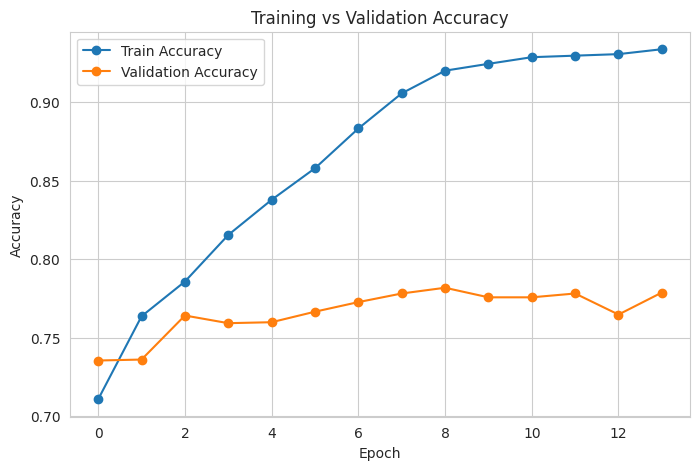

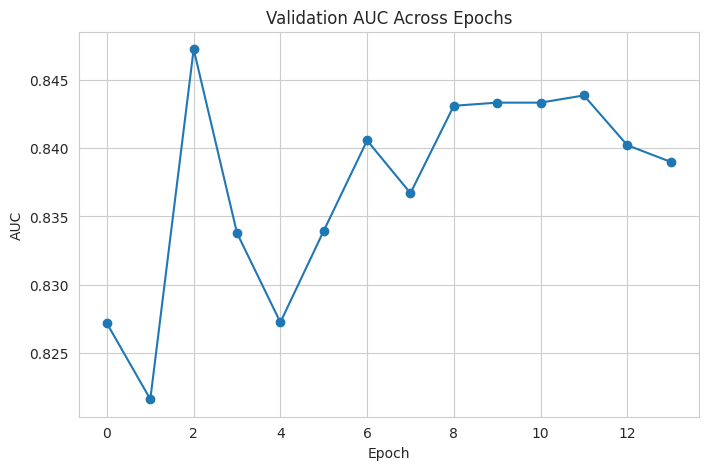

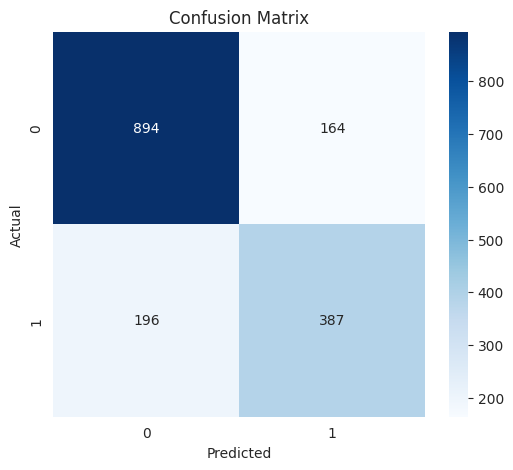

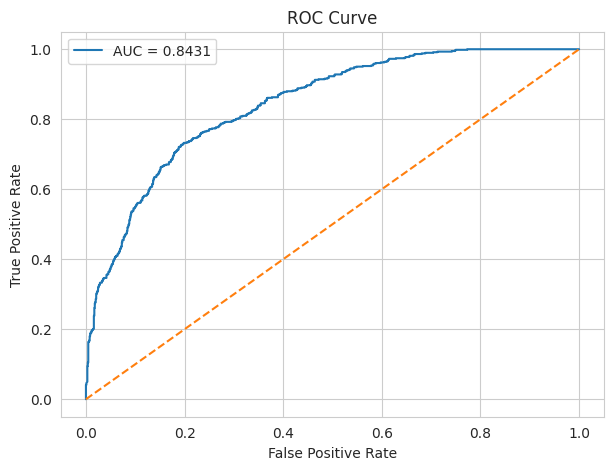

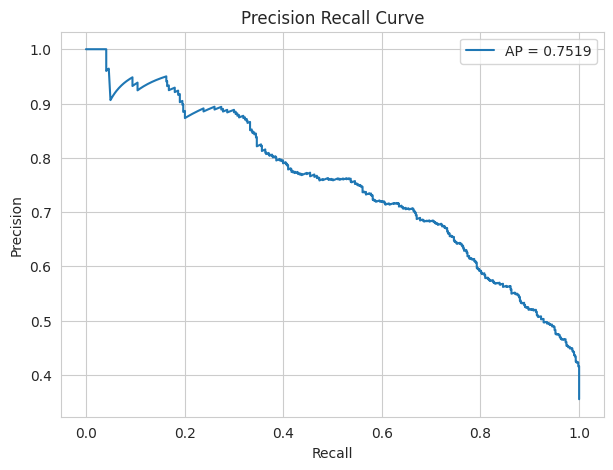

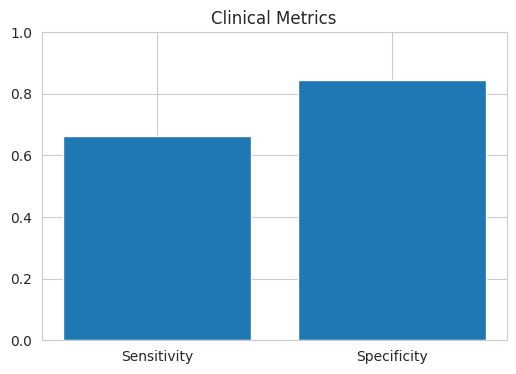

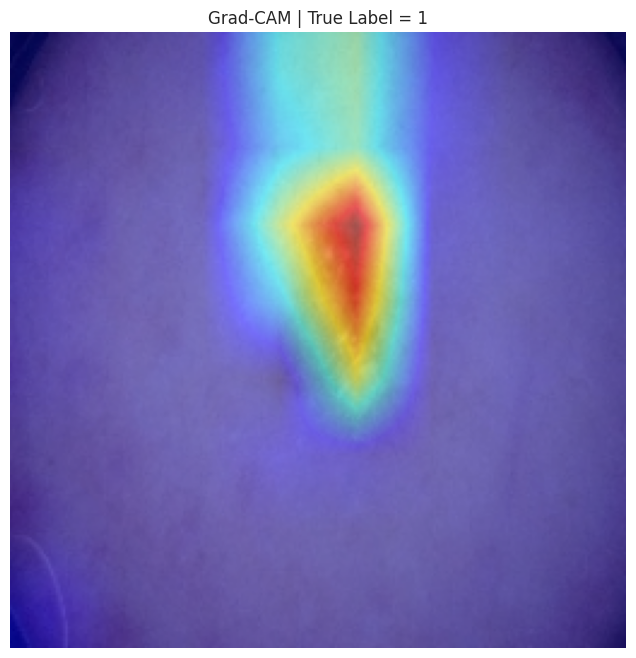

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


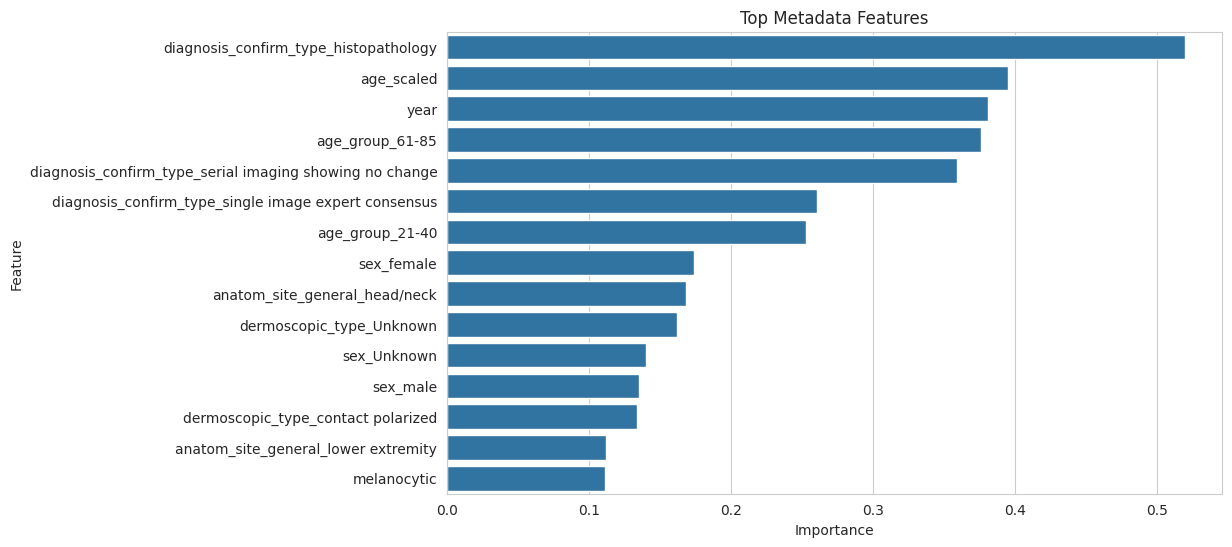

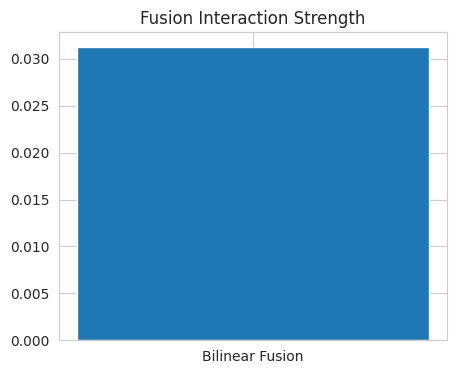

Most Confident Prediction Index: 116
Least Confident Prediction Index: 411
FULL XAI REPORT GENERATED.


In [11]:
# ============================================================
# FULL FINAL XAI + GRAPHS CODE (FIXED VERSION)
# ConvNeXt + FT-Transformer + Bilinear Fusion
# Kaggle Ready
# Run AFTER training finished
# Requires:
# model class defined
# feature_cols
# val_df
# val_loader
# val_tfms
# history
# best_convnext_ft_bilinear.pth
# ============================================================

!pip install -q grad-cam shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD MODEL
# ============================================================
model = ConvNeXtFTBilinear(len(feature_cols)).to(device)

model.load_state_dict(
    torch.load(
        "best_convnext_ft_bilinear.pth",
        map_location=device
    )
)

model.eval()

# ============================================================
# REBUILD DATASET
# ============================================================
val_ds = SkinDataset(val_df, val_tfms)

# ============================================================
# PREDICTIONS
# ============================================================
val_true  = []
val_preds = []
val_probs = []

with torch.no_grad():

    for images, meta, labels in tqdm(val_loader):

        images = images.to(device)
        meta   = meta.to(device)

        outputs = model(images, meta)

        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = outputs.argmax(1)

        val_true.extend(labels.numpy())
        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())

val_true  = np.array(val_true)
val_preds = np.array(val_preds)
val_probs = np.array(val_probs)

# ============================================================
# REPORT
# ============================================================
print(classification_report(val_true, val_preds))

# ============================================================
# 1. TRAINING CURVES
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["val_auc"], marker="o")
plt.title("Validation AUC Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 3. ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 4. PR CURVE
# ============================================================
precision, recall, _ = precision_recall_curve(
    val_true,
    val_probs
)

ap = average_precision_score(
    val_true,
    val_probs
)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# ============================================================
# 5. CLINICAL METRICS
# ============================================================
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

plt.figure(figsize=(6,4))
plt.bar(
    ["Sensitivity", "Specificity"],
    [sensitivity, specificity]
)
plt.ylim(0,1)
plt.title("Clinical Metrics")
plt.show()

# ============================================================
# 6. GRAD-CAM
# ============================================================

img, meta, label = val_ds[0]

input_tensor = img.unsqueeze(0).to(device)
meta_tensor  = meta.unsqueeze(0).to(device)

class Wrapper(torch.nn.Module):
    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta

    def forward(self, x):
        return self.model(x, self.meta)

wrapped_model = Wrapper(model, meta_tensor).to(device)
wrapped_model.eval()

target_layers = [
    wrapped_model.model.backbone[-1]
]

cam = GradCAM(
    model=wrapped_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (
    img_np.max() - img_np.min()
)

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title(f"Grad-CAM | True Label = {label.item()}")
plt.axis("off")
plt.show()

# ============================================================
# 7. METADATA IMPORTANCE (FIXED)
# ============================================================
importance = []

for col in feature_cols:

    vals = val_df[col].values.astype(float)

    score = np.corrcoef(vals, val_probs)[0,1]

    if np.isnan(score):
        score = 0

    importance.append(abs(score))

imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=imp_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Metadata Features")
plt.show()

# ============================================================
# 8. FUSION STRENGTH
# ============================================================
b = model.bilinear.weight.detach().cpu().numpy()

fusion_strength = np.mean(np.abs(b))

plt.figure(figsize=(5,4))
plt.bar(
    ["Bilinear Fusion"],
    [fusion_strength]
)
plt.title("Fusion Interaction Strength")
plt.show()

# ============================================================
# 9. BEST / WORST EXAMPLES
# ============================================================
confidence = np.abs(val_probs - 0.5)

best_idx = np.argmax(confidence)
worst_idx = np.argmin(confidence)

print("Most Confident Prediction Index:", best_idx)
print("Least Confident Prediction Index:", worst_idx)

# ============================================================
# DONE
# ============================================================
print("FULL XAI REPORT GENERATED.")

In [12]:
# ============================================================
# GENERALIZATION-OPTIMIZED MODEL
# EfficientNetV2-S + Gated Fusion
# Built to REDUCE Train/Validation Gap
# Kaggle GPU Ready
# ============================================================

import os, gc, time, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# GPU SPEED
# ============================================================
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# PATHS
# ============================================================
DATA_PATH = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset"
IMG_PATH  = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
CSV_PATH  = "/kaggle/input/datasets/abdelrahmanelkassem/project/final_preprocessed_data.csv"

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
available = set(os.listdir(IMG_PATH))

def clean_name(x):
    x = str(x)
    x = x.replace("_mel.jpg",".jpg")
    x = x.replace("_oth.jpg",".jpg")
    x = x.replace("ISIC2019_","ISIC_")
    x = x.replace("ISIC2020_","ISIC_")
    x = x.replace("ISIC2018_","ISIC_")
    x = x.replace("ISIC2017_","ISIC_")
    return x

df["image"] = df["image"].apply(clean_name)
df = df[df["image"].isin(available)].reset_index(drop=True)

# ============================================================
# FEATURES
# ============================================================
drop_cols = ["image","class","isic_id","patient_id"]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

# ============================================================
# PATIENT SAFE SPLIT
# ============================================================
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

# ============================================================
# STRONGER AUGMENTATION
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((280,280)),
    transforms.RandomResizedCrop(
        256,
        scale=(0.85,1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.03
    ),
    transforms.RandomAutocontrast(p=0.2),
    transforms.GaussianBlur(3, sigma=(0.1,1.5)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# ============================================================
# DATASET
# ============================================================
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            os.path.join(IMG_PATH, row["image"])
        ).convert("RGB")

        img = self.transform(img)

        meta = torch.tensor(
            row[feature_cols].values.astype(np.float32)
        )

        label = torch.tensor(
            int(row["class"])
        ).long()

        return img, meta, label

# ============================================================
# BALANCED SAMPLER
# ============================================================
labels = train_df["class"].values
counts = np.bincount(labels)
weights = 1.0 / counts
sample_weights = [weights[x] for x in labels]

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    len(sample_weights)
)

# ============================================================
# LOADERS
# ============================================================
train_loader = DataLoader(
    SkinDataset(train_df, train_tfms),
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    SkinDataset(val_df, val_tfms),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# SWISH
# ============================================================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# ============================================================
# MODEL (SMALLER HEAD = BETTER GENERALIZATION)
# ============================================================
class EfficientNetV2Generalized(nn.Module):

    def __init__(self, meta_dim):
        super().__init__()

        backbone = models.efficientnet_v2_s(weights="DEFAULT")

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.img_fc = nn.Sequential(
            nn.Linear(1280,192),
            Swish(),
            nn.Dropout(0.35)
        )

        self.meta_fc = nn.Sequential(
            nn.Linear(meta_dim,64),
            Swish(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.35)
        )

        self.gate = nn.Sequential(
            nn.Linear(256,64),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(256,96),
            Swish(),
            nn.Dropout(0.5),
            nn.Linear(96,2)
        )

    def forward(self, image, meta):

        x = self.features(image)
        x = self.pool(x).flatten(1)

        img_feat = self.img_fc(x)
        meta_feat = self.meta_fc(meta)

        fused = torch.cat([img_feat, meta_feat], dim=1)

        gate = self.gate(fused)
        meta_feat = meta_feat * gate

        fused = torch.cat([img_feat, meta_feat], dim=1)

        return self.classifier(fused)

model = EfficientNetV2Generalized(
    len(feature_cols)
).to(device)

# ============================================================
# LABEL SMOOTHING LOSS
# ============================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=4,
    T_mult=2
)

scaler = GradScaler()

# ============================================================
# TRAIN LOOP
# ============================================================
best_auc = 0
patience = 4
counter = 0
EPOCHS = 20

history = {
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(EPOCHS):

    model.train()

    train_preds = []
    train_true = []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, meta, labels in loop:

        images = images.to(device, non_blocking=True)
        meta   = meta.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images, meta)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(1)

        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

        loop.set_postfix(loss=float(loss))

    train_acc = accuracy_score(train_true, train_preds)

    # ================= VALIDATION =================
    model.eval()

    val_preds = []
    val_probs = []
    val_true  = []

    with torch.no_grad():

        for images, meta, labels in tqdm(
            val_loader,
            desc="Validating"
        ):

            images = images.to(device, non_blocking=True)
            meta   = meta.to(device, non_blocking=True)

            with autocast():
                outputs = model(images, meta)

            probs = torch.softmax(outputs,1)[:,1]
            preds = outputs.argmax(1)

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        counter = 0
        torch.save(
            model.state_dict(),
            "best_generalized_model.pth"
        )
        print("BEST MODEL SAVED")
    else:
        counter += 1

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc  : {val_acc:.4f}")
    print(f"Val AUC  : {val_auc:.4f}")
    print("-"*50)

    if counter >= patience:
        print("EARLY STOPPING")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("Best Validation AUC:", best_auc)

Using: cuda
GPU: Tesla T4
Train: 15378
Val: 1641
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 154MB/s] 
/tmp/ipykernel_55/3437598333.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/20:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/3437598333.py:312: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

...

Epoch 8/20:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/3437598333.py:312: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/52 [00:00<?, ?it/s]

/tmp/ipykernel_55/3437598333.py:346: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 8
Train Acc: 0.9211
Val Acc  : 0.7983
Val AUC  : 0.8889
--------------------------------------------------
EARLY STOPPING
Best Validation AUC: 0.9051634690522589


  0%|          | 0/52 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1058
           1       0.78      0.66      0.71       583

    accuracy                           0.81      1641
   macro avg       0.80      0.78      0.79      1641
weighted avg       0.81      0.81      0.81      1641

F1 Score: 0.7113594040968343


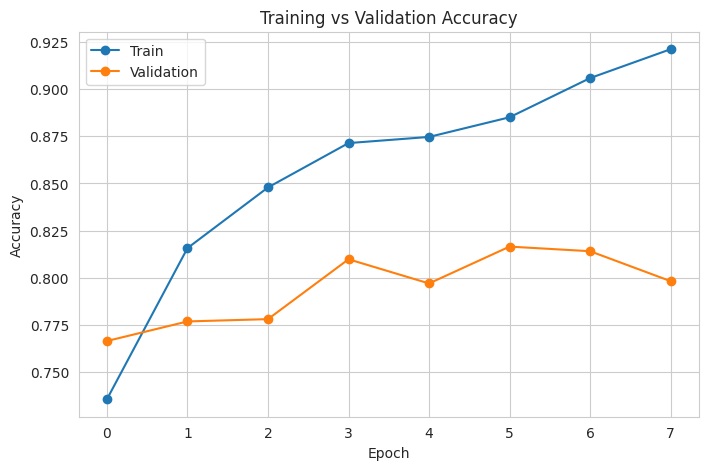

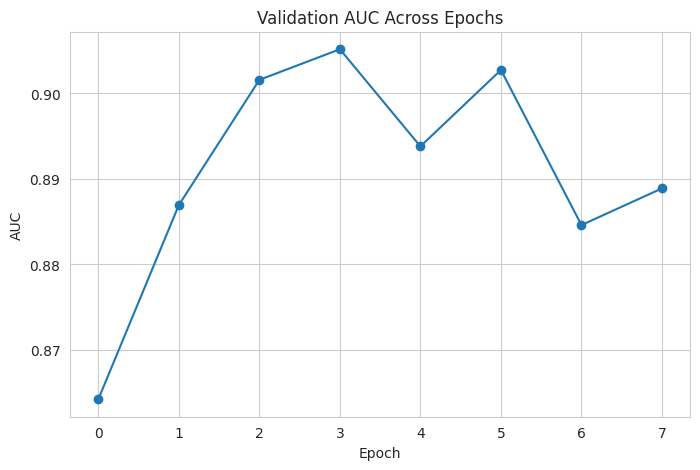

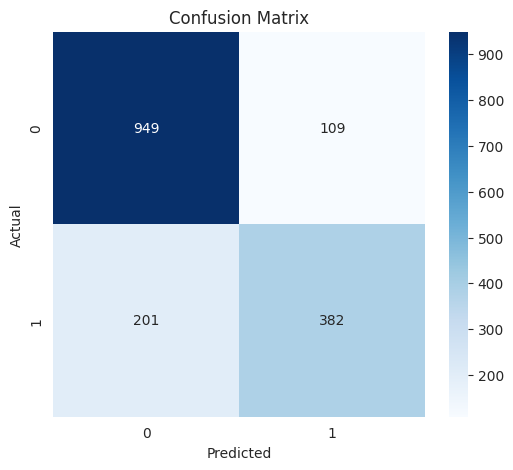

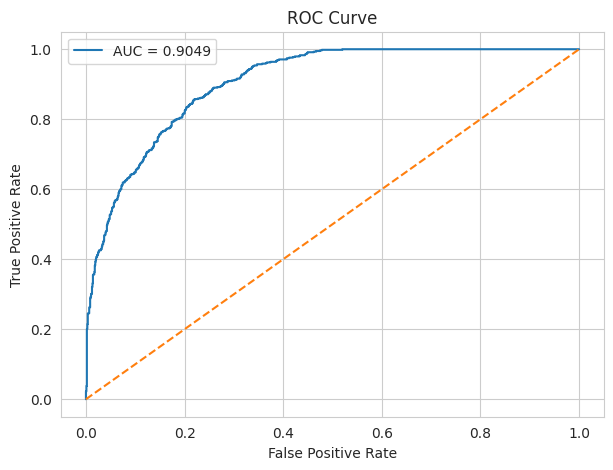

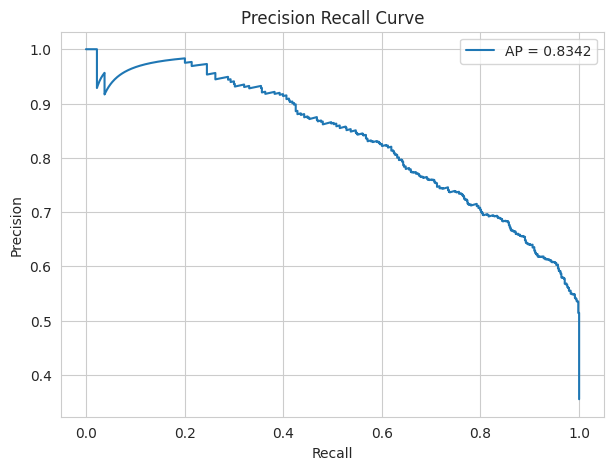

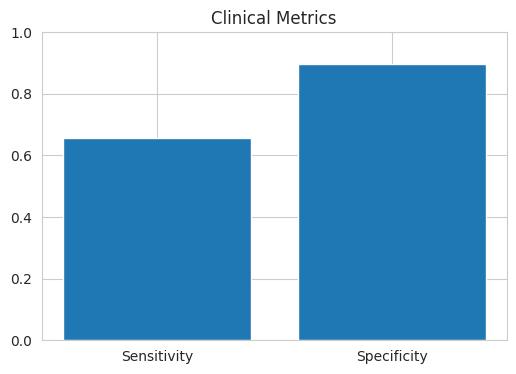

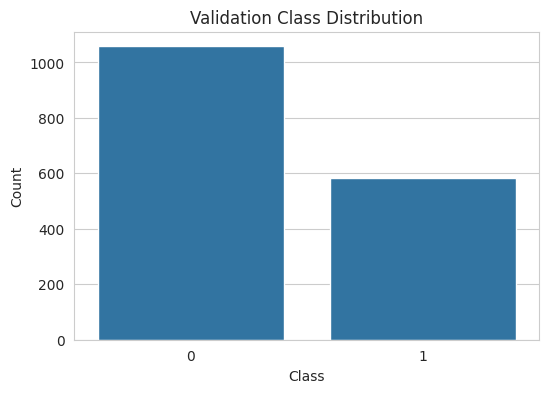

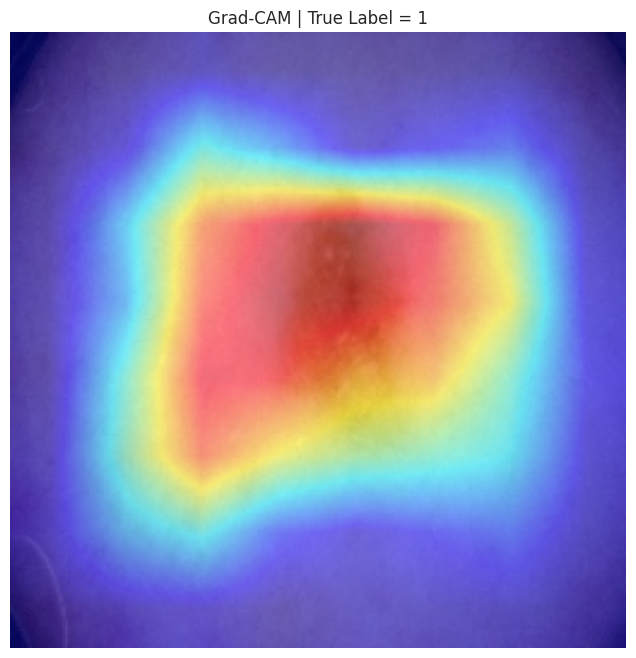

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


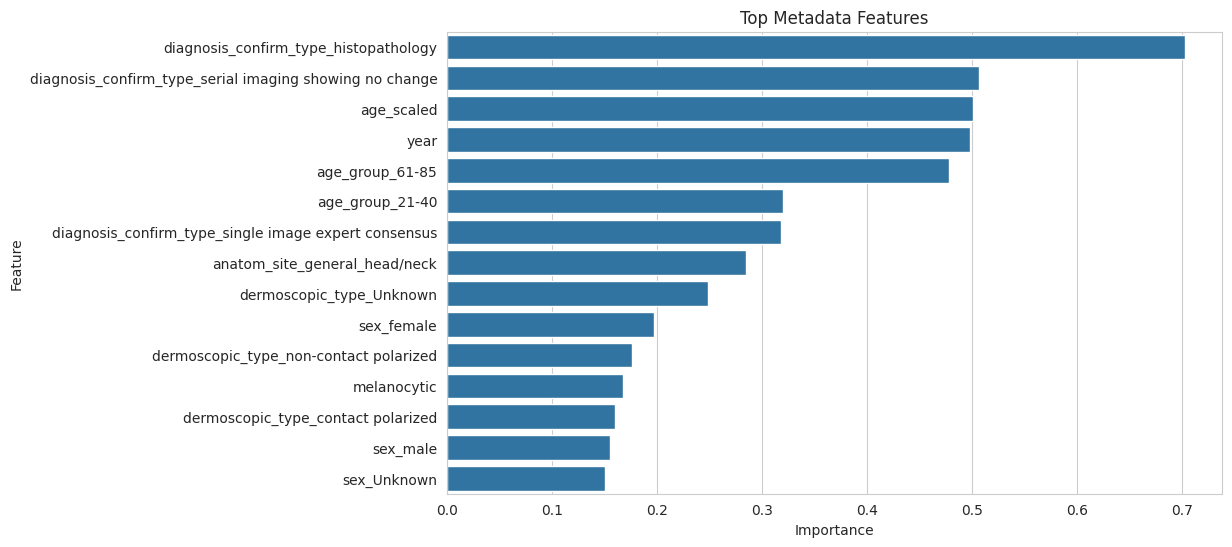

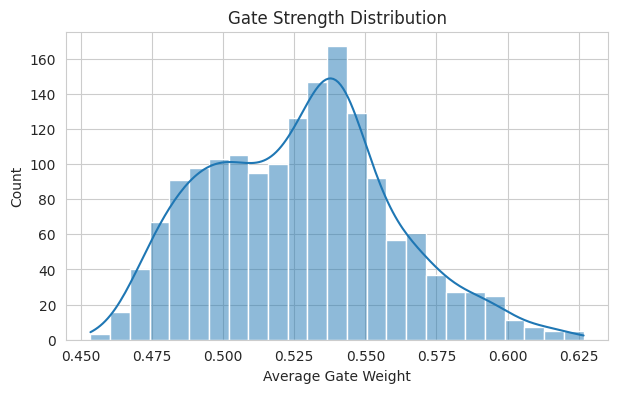

Most confident sample index: 459
Least confident sample index: 1233
FULL XAI REPORT GENERATED.


In [13]:
# ============================================================
# FULL XAI + GRAPHS
# EfficientNetV2Generalized Model
# Kaggle Ready
# Run AFTER training finishes
# Uses:
# best_generalized_model.pth
# history
# val_df
# val_loader
# val_tfms
# feature_cols
# model class already defined
# ============================================================

!pip install -q grad-cam shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    f1_score
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD MODEL
# ============================================================
model = EfficientNetV2Generalized(
    len(feature_cols)
).to(device)

model.load_state_dict(
    torch.load(
        "best_generalized_model.pth",
        map_location=device
    )
)

model.eval()

# ============================================================
# REBUILD VALIDATION DATASET
# ============================================================
val_ds = SkinDataset(val_df, val_tfms)

# ============================================================
# PREDICTIONS
# ============================================================
val_true  = []
val_preds = []
val_probs = []

with torch.no_grad():

    for images, meta, labels in tqdm(val_loader):

        images = images.to(device)
        meta   = meta.to(device)

        outputs = model(images, meta)

        probs = torch.softmax(outputs, dim=1)[:,1]
        preds = outputs.argmax(1)

        val_true.extend(labels.numpy())
        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())

val_true  = np.array(val_true)
val_preds = np.array(val_preds)
val_probs = np.array(val_probs)

# ============================================================
# REPORT
# ============================================================
print(classification_report(val_true, val_preds))
print("F1 Score:", f1_score(val_true, val_preds))

# ============================================================
# 1. TRAINING ACCURACY CURVE
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], marker="o", label="Train")
plt.plot(history["val_acc"], marker="o", label="Validation")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ============================================================
# 2. VALIDATION AUC CURVE
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history["val_auc"], marker="o")
plt.title("Validation AUC Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

# ============================================================
# 3. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 4. ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 5. PRECISION RECALL CURVE
# ============================================================
precision, recall, _ = precision_recall_curve(
    val_true,
    val_probs
)

ap = average_precision_score(
    val_true,
    val_probs
)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# ============================================================
# 6. CLINICAL METRICS
# ============================================================
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

plt.figure(figsize=(6,4))
plt.bar(
    ["Sensitivity", "Specificity"],
    [sensitivity, specificity]
)
plt.ylim(0,1)
plt.title("Clinical Metrics")
plt.show()

# ============================================================
# 7. CLASS DISTRIBUTION
# ============================================================
plt.figure(figsize=(6,4))
sns.countplot(x=val_true)
plt.title("Validation Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ============================================================
# 8. GRAD-CAM
# ============================================================

img, meta, label = val_ds[0]

input_tensor = img.unsqueeze(0).to(device)
meta_tensor  = meta.unsqueeze(0).to(device)

class Wrapper(torch.nn.Module):
    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta

    def forward(self, x):
        return self.model(x, self.meta)

wrapped_model = Wrapper(model, meta_tensor).to(device)
wrapped_model.eval()

target_layers = [
    wrapped_model.model.features[-1]
]

cam = GradCAM(
    model=wrapped_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (
    img_np.max() - img_np.min()
)

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title(f"Grad-CAM | True Label = {label.item()}")
plt.axis("off")
plt.show()

# ============================================================
# 9. METADATA IMPORTANCE
# ============================================================
importance = []

for col in feature_cols:

    vals = val_df[col].values.astype(float)

    score = np.corrcoef(vals, val_probs)[0,1]

    if np.isnan(score):
        score = 0

    importance.append(abs(score))

imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=imp_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Metadata Features")
plt.show()

# ============================================================
# 10. GATE STRENGTH
# ============================================================
gate_weights = []

with torch.no_grad():

    for images, meta, labels in val_loader:

        images = images.to(device)
        meta   = meta.to(device)

        x = model.features(images)
        x = model.pool(x).flatten(1)

        img_feat = model.img_fc(x)
        meta_feat = model.meta_fc(meta)

        fused = torch.cat([img_feat, meta_feat], dim=1)

        gate = model.gate(fused)

        gate_weights.extend(
            gate.mean(dim=1).cpu().numpy()
        )

plt.figure(figsize=(7,4))
sns.histplot(gate_weights, bins=25, kde=True)
plt.title("Gate Strength Distribution")
plt.xlabel("Average Gate Weight")
plt.show()

# ============================================================
# 11. MOST / LEAST CONFIDENT CASES
# ============================================================
confidence = np.abs(val_probs - 0.5)

print("Most confident sample index:", np.argmax(confidence))
print("Least confident sample index:", np.argmin(confidence))

# ============================================================
# DONE
# ============================================================
print("FULL XAI REPORT GENERATED.")